# Atmospheric River Intensity Trends at a West Coast Location (1980–2024)

## Overview

Atmospheric Rivers (ARs) are narrow corridors of strong water vapor transport that deliver a significant portion of annual precipitation to the U.S. West Coast.
In this assignment, I analyze how often ARs of different intensities (1–5) make landfall at Pasadena, CA and how this frequency has changed over time.

I use an existing PIKART Global catalogue of atmospheric rivers and perform a statistical analysis of AR intensity trends from 19YY–2024.


In [1]:
# Import required libraries
from siphon.catalog import TDSCatalog            # For accessing the THREDDS catalog
import matplotlib.pyplot as plt                  # For plotting
import numpy as np                               # For numerical array operations
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs                       # For cartographic projections
import cartopy.feature as cfeature               # For adding geographical features
import datetime                                  # For handling time conversion

print('labraries imported')

labraries imported


The next cell accesses and reads the dataset without downloading it.
Instead, the data is streamed on demand whenever specific variables or time slices are requested.

- *Siphon* is used to read the THREDDS catalog and obtain a directory-style list of all available files.

- *OPeNDAP* is then used to remotely access the selected dataset, allowing xarray to open and read variables directly from the server without storing the full NetCDF file locally.

In [2]:
# Script to remotely access PIKART Lagrangian data 
# ===========================================================================


# URL of dataset
# Define the base URL of the THREDDS Data Server catalog
catUrl = "https://ar.pik-potsdam.de/thredds/catalog/lagrangian_era5/catalog.xml"

# Select the year of interest for which data will be accessed
year = '2020'
#year = range(2000, 2022)

# Construct the specific dataset filename using the selected year
datasetName = f"PIKARTV1_lagrangian_ERA5_0p5deg_6hr_{year}.nc"

# Load the catalog using Siphon
catalog = TDSCatalog(catUrl)

# Access the specific dataset object from the catalog
ds = catalog.datasets[datasetName]

# Optional: Inspect dataset name
ds.name

# Remote access to dataset

# Use remote_access() to open the dataset via OPeNDAP
# This allows you to read data directly without downloading the full file
dataset = ds.remote_access()

print('ready')

ready


In [ ]:
# explore the dataset
dataset

The PIKART landfall variable lf_loc provides coastal landfall latitude, not inland location. Thus, I need to choose a latitude window around Pasadena’s coastal latitude band. This ensures catch ARs that make landfall in Southern California before affecting Pasadena.

In [3]:
# Pasadena location (lat +/- 2 degrees)
lat_pas = 34.156
lat_min = lat_pas - 2
lat_max = lat_pas + 2

# South California coastal longitude window
lon_min = -125
lon_max = -114


print('ready')

ready


Atmospheric rivers are categorized into five levels: from AR 1 (Weak) to AR 5 (Exceptional), based on their Integrated Water Vapor Transport (IVT) and duration.
**STEPS**
- STEP 1 — Find which AR tracks ever make landfall
- STEP 2 — Find WHEN and WHERE each AR hits land
- STEP 3 — Full AR track analysis (including IVT and duration)

In [4]:
opendap_url = ds.access_urls["OPENDAP"]
dataset = xr.open_dataset(opendap_url)

print('ready')

ready


In [5]:
# ==============================================================
# 1. Extract variables from the dataset
# ==============================================================

trackid = dataset["trackid"]           # trackid dimension: identifies each AR track    
land_falling = dataset["land_falling"] # land-falling indicator (1 = landfall event at this time step)

lf_loc = dataset["lf_loc"]             # landfall coordinates (coordinate=0: lat, coordinate=1: lon)

ivt = dataset["core_ivt"]              # IVT core (component=0 is magnitude) 

decoded_time = xr.decode_cf(dataset)[["time"]].indexes["time"] # Time coordinate decoded from CF metadata

print("Variables loaded.")

Variables loaded.


In [6]:
# ==============================================================
# 2. Select  tracks that make landfall in this year
# ==============================================================

landfall_tracks = trackid.where(land_falling == 1, drop=True)  # Keep only the trackid values at those times where land_falling == 1,
                                                               # and remove all other data.

if len(landfall_tracks) == 0:
    print("No landfalling ARs found in this dataset.")
    raise SystemExit                                           # This protects the rest of the code from crashing.(ChatGPT recomendation)

print(f"Found {len(landfall_tracks)} landfalling AR track IDs.")

Found 500 landfalling AR track IDs.


In [7]:
# =================================================================
# 3. Extract landfall timestep, latitude & longitude for each track 
# =================================================================

lf = lf_loc.sel(trackid=landfall_tracks)               # Extract landfall coordinates ONLY for tracks that actually made landfall

lat_all = lf.sel(coordinate=0)                         # Separate latitude and longitude
lon360 = lf.sel(coordinate=1)

lon_all = ((lon360 + 180) % 360) - 180                 # Convert lon from 0–360 into -180..180

valid = np.isfinite(lat_all) & np.isfinite(lon_all)    # Identify WHICH time steps contain valid landfall coordinates
 
first_idx = valid.argmax(dim="time")                   # Identify WHICH time steps contain valid landfall coordinates

print("Landfall coordinates extracted.")

Landfall coordinates extracted.


In [8]:
# ==============================================================
# 4. Storage lists for AR landfall values
# ==============================================================

lf_lats = []
lf_lons = []
lf_ivt_peak = []
lf_duration = []
lf_category = []

print ('done')

done


**Big Loop**

It goes over each landfalling atmospheric river and:
 - Finds its first landfall location
 - Gets its IVT time series
 - Computes peak IVT
 - Computes AR duration
 - Assigns AR category (AR1–AR5)
 - Applies duration bump
 - Stores results in a table

    It was written by ChatGPT as the respond to request "add to exicting code next step that would categorize AR on IVT and also on duration of AR." a few following adjusments were done.

In [9]:
# ==============================================================
# 5. LOOP through each AR track
# ==============================================================

for n in range(len(landfall_tracks)):

    # Track ID
    ti = int(landfall_tracks[n])

    # Skip tracks with no valid landfall
    if not valid.sel(trackid=ti).any():
        continue

    # First landfall time index
    idx = int(first_idx.sel(trackid=ti))

    # Landfall lat/lon
    this_lat = float(lat_all.sel(trackid=ti).isel(time=idx))
    this_lon = float(lon_all.sel(trackid=ti).isel(time=idx))

    # Filter to Pasadena region
    if not (lat_min <= this_lat <= lat_max and lon_min <= this_lon <= lon_max):
        continue

    # Full IVT time series for this track
    ivt_track = ivt.sel(trackid=ti, component=0)

    # Peak IVT
    ivt_peak = float(ivt_track.max())

    # Duration: hours with IVT ≥ 250 (embedded AR condition)
    mask = (ivt_track >= 250)
    duration_hrs = int(mask.sum())

    # =======================================================
    # Assign base category using IVT intensity
    # =======================================================
    if ivt_peak < 250:
        base_cat = None
    elif ivt_peak < 500:
        base_cat = 1
    elif ivt_peak < 750:
        base_cat = 2
    elif ivt_peak < 1000:
        base_cat = 3
    elif ivt_peak < 1250:
        base_cat = 4
    else:
        base_cat = 5

    # =======================================================
    # Duration bump (+1 if ≥48 hours)
    # =======================================================
    if base_cat is None:
        final_cat = None
    else:
        final_cat = base_cat
        if duration_hrs >= 48:
            final_cat += 1
        if final_cat > 5:
            final_cat = 5

    # Save values
    lf_lats.append(this_lat)
    lf_lons.append(this_lon)
    lf_ivt_peak.append(ivt_peak)
    lf_duration.append(duration_hrs)
    lf_category.append(final_cat)


print("Loop finished.")


# ==============================================================
# 6. BUILD DATAFRAME WITH RESULTS
# ==============================================================

df = pd.DataFrame({
    "lat": lf_lats,
    "lon": lf_lons,
    "ivt_peak": lf_ivt_peak,
    "duration_hr": lf_duration,
    "category": lf_category
})

print("\nFinal Landfall AR Table:")
print(df)

Loop finished.

Final Landfall AR Table:
     lat    lon    ivt_peak  duration_hr  category
0  34.75 -120.5  616.426514            4         2
1  34.75 -120.5  581.413513            3         2


To create the next plot I asked ChatGPT to add Pasadena location and x,y axis that will show longitude and latitude.

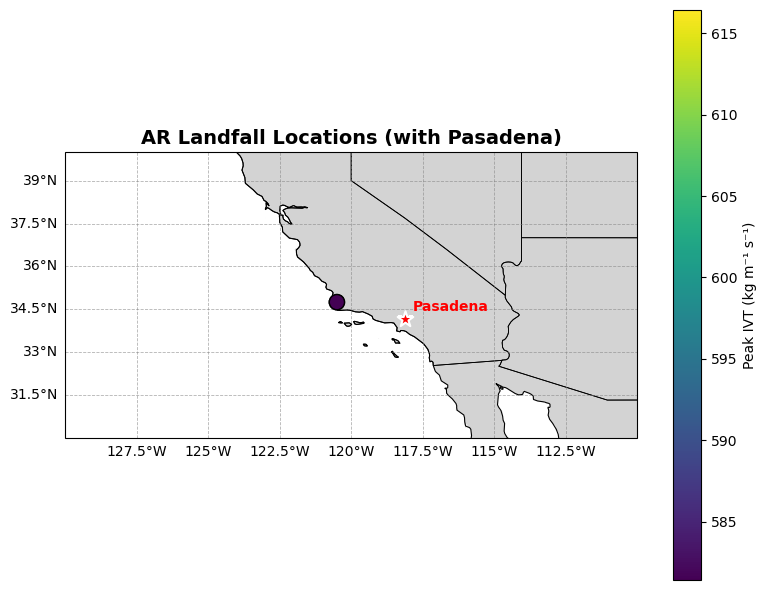

In [10]:
pas_lat = 34.156
pas_lon = -118.131    # approximately

plt.figure(figsize=(8, 6))

ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-130, -110, 30, 40])  # Southern California region

# Map features
ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.8)
ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.6)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="lightgray")

# --------------------------------------------------------------
# Scatter points for AR landfall
# --------------------------------------------------------------
sc = ax.scatter(
    df["lon"], df["lat"],
    c=df["ivt_peak"],
    cmap="viridis",
    s=120,
    edgecolor="k",
    transform=ccrs.PlateCarree(),
    zorder=3
)

# --------------------------------------------------------------
# Pasadena reference point
# --------------------------------------------------------------
ax.scatter(
    pas_lon, pas_lat,
    color="red",
    s=140,
    edgecolor="white",
    linewidth=1.5,
    marker="*",
    transform=ccrs.PlateCarree(),
    zorder=4
)

ax.text(
    pas_lon + 0.3, pas_lat + 0.3,
    "Pasadena",
    fontsize=10,
    fontweight="bold",
    color="red",
    transform=ccrs.PlateCarree(),
    zorder=4
)

# --------------------------------------------------------------
# ✅ Show latitude and longitude axes
# --------------------------------------------------------------
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.6,
    color='gray',
    alpha=0.6,
    linestyle='--'
)

gl.top_labels = False    # turn off labels on top
gl.right_labels = False  # turn off labels on right

# --------------------------------------------------------------
# Colorbar and title
# --------------------------------------------------------------
cbar = plt.colorbar(sc, ax=ax, label="Peak IVT (kg m⁻¹ s⁻¹)")
ax.set_title("AR Landfall Locations (with Pasadena)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("AR_landfall.png", dpi=300, bbox_inches="tight")
plt.show()


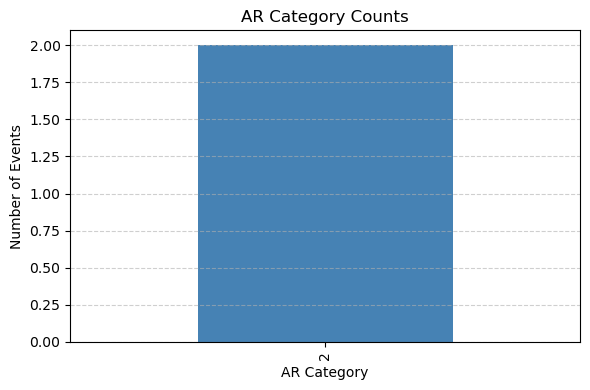

In [11]:
# ==============================================================
# PLOT 2 — Number of ARs per Category
# ==============================================================

plt.figure(figsize=(6,4))
df["category"].value_counts().sort_index().plot(kind="bar", color="steelblue")

plt.title("AR Category Counts")
plt.xlabel("AR Category")
plt.ylabel("Number of Events")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("AR number.png", dpi=300, bbox_inches="tight")

plt.show()


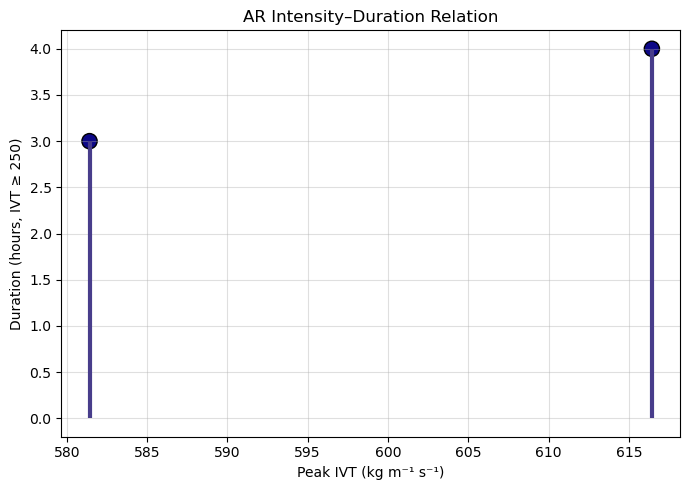

In [12]:
# ==============================================================
# PLOT 3 — IVT vs Duration (“sticks” plot)
# ==============================================================

plt.figure(figsize=(7,5))

plt.vlines(
    x=df["ivt_peak"],
    ymin=0,
    ymax=df["duration_hr"],
    color="darkslateblue",
    linewidth=3
)

plt.scatter(
    df["ivt_peak"],
    df["duration_hr"],
    c=df["category"],
    cmap="plasma",
    s=120,
    edgecolor="k"
)

plt.xlabel("Peak IVT (kg m⁻¹ s⁻¹)")
plt.ylabel("Duration (hours, IVT ≥ 250)")
plt.title("AR Intensity–Duration Relation")

plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig("AR Intensity-Duration.png", dpi=300, bbox_inches="tight")

plt.show()


## Summary
This notebook demonstrates how physical interpretation, data filtering, and computational tools integrate to support rigorous AR diagnostics and advance our understanding of regional AR behavior.

## Referencies
1. Atmospheric Rivers defenition: https://psl.noaa.gov/arportal/about/
2. Dataset catalog: https://ar.pik-potsdam.de/thredds/catalog/lagrangian_era5/catalog.html
